In [1]:
#Імпортуємо всі необхідні бібліотеки
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
from PIL import Image
import pathlib
import csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import keras
from keras import layers
from keras import layers
import keras
from keras.models import Sequential
import warnings
warnings.filterwarnings('ignore')


In [2]:
cmap = plt.get_cmap('inferno')
plt.figure(figsize=(8, 8))

# Список інструментів
instruments = 'sax flute viola cello trumpet oboe'.split()

# Шлях до аудіофайлів
base_path = r'C:\Users\Вовчик\Downloads\london_phill_dataset_multi\london_phill_dataset_multi'

# Створення спектрограм для кожного інструмента
for instrument in instruments:
    instrument_path = os.path.join(base_path, instrument)
    output_path = os.path.join('img_data', instrument)
    pathlib.Path(output_path).mkdir(parents=True, exist_ok=True)
    
    for filename in os.listdir(instrument_path):
        audioname = os.path.join(instrument_path, filename)
        try:
            y, sr = librosa.load(audioname, mono=True, duration=5)
            plt.specgram(y, NFFT=2048, Fs=2, Fc=0, noverlap=128, cmap=cmap, sides='default', mode='default', scale='dB')
            plt.axis('off')
            plt.savefig(os.path.join(output_path, f'{filename[:-4]}.png'))
            plt.clf()
        except Exception as e:
            print(f"Error loading {audioname}. Error: {e}")


<Figure size 800x800 with 0 Axes>

In [3]:
#Створюємо файл CSV для збереження в нього даних
header = 'filename chroma_stft rmse spectral_centroid spectral_bandwidth rolloff zero_crossing_rate'
for i in range(1, 21):
    header += f' mfcc{i}'
header += ' label'
header = header.split()

In [4]:
csv_file_path = r'dataset.csv'

# Створення заголовка для CSV файлу
header = 'filename chroma_stft rmse spectral_centroid spectral_bandwidth rolloff zero_crossing_rate'
for i in range(1, 21):
    header += f' mfcc{i}'
header += ' label'
header = header.split()

# Запис заголовка у CSV файл
with open(csv_file_path, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(header)

instruments = 'sax flute viola cello trumpet oboe'.split()

# Отримання ознак та запис у CSV файл
for instrument in instruments:
    instrument_path = os.path.join(base_path, instrument)
    for filename in os.listdir(instrument_path):
        audioname = os.path.join(instrument_path, filename)
        try:
            y, sr = librosa.load(audioname, mono=True, duration=30)
            rmse = librosa.feature.rms(y=y)
            chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
            spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
            spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
            rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
            zcr = librosa.feature.zero_crossing_rate(y)
            mfcc = librosa.feature.mfcc(y=y, sr=sr)
            to_append = f'{filename} {np.mean(chroma_stft)} {np.mean(rmse)} {np.mean(spec_cent)} {np.mean(spec_bw)} {np.mean(rolloff)} {np.mean(zcr)}'
            for e in mfcc:
                to_append += f' {np.mean(e)}'
            to_append += f' {instrument}'
            with open(csv_file_path, 'a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow(to_append.split())
        except Exception as e:
            print(f"Error processing {audioname}. Error: {e}")


In [5]:
# Обробка даних
data = pd.read_csv(csv_file_path)
print(data.head())

# Видалення непотрібних стовпчиків
data = data.drop(['filename'], axis=1)

# Створення міток
instrument_list = data.iloc[:, -1]
encoder = LabelEncoder()
y = encoder.fit_transform(instrument_list)

# Масштабування стовпчиків ознак
scaler = StandardScaler()
X = scaler.fit_transform(np.array(data.iloc[:, :-1], dtype=float))

# Розділення даних на навчальний та тестовий набір
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Перевірка результатів
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

                                  filename  chroma_stft      rmse  \
0        saxophone_A3_025_forte_normal.mp3     0.322156  0.026990   
1   saxophone_A3_025_fortissimo_normal.mp3     0.331868  0.030299   
2  saxophone_A3_025_mezzo-piano_normal.mp3     0.301408  0.023705   
3   saxophone_A3_025_pianissimo_normal.mp3     0.303428  0.025234   
4         saxophone_A3_05_forte_normal.mp3     0.246268  0.032016   

   spectral_centroid  spectral_bandwidth      rolloff  zero_crossing_rate  \
0        1708.984682         1888.267560  3552.081299            0.056519   
1        1738.263129         1897.762878  3100.781250            0.075765   
2        1422.253167         1750.194754  2769.323730            0.052909   
3         885.094253         1149.393252  1429.266357            0.059001   
4        1558.447324         1593.848677  3038.424683            0.055318   

        mfcc1       mfcc2      mfcc3  ...     mfcc12    mfcc13    mfcc14  \
0 -446.552002  101.640511 -22.164816  ... -11.

In [6]:
#Створюємо і підлаштовуємо модель ANN
model = Sequential()
model.add(layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

classifier = model.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=128)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.2046 - loss: 2.2385
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6011 - loss: 1.8208 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6629 - loss: 1.4565 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6793 - loss: 1.1460 
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7389 - loss: 0.8628 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8821 - loss: 0.5815 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9362 - loss: 0.3751 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9278 - loss: 0.2826 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9544 - loss: 0.1882 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9593 - loss: 0.1546 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9829 - loss: 0.1109 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9785 - loss: 0.0305 
Test accuracy: 0.9750
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Classification Report:
              precision    recall  f1-score   support

       cello       1.00      0.88      0.94        17
       flute       1.00      1.00      1.00        20
        oboe       1.00      0.96      0.98        24
         sax       1.00      1.00      1.00        23
     trumpet       0.94      1.00      0.97        17
       viola       0.90      1.00      0.95        19

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120

Confusion Matrix:
[[15  0  0  0  0  2]
 [ 0 20  0  0  0  0]
 [ 0  0 23  0  1  0]
 [ 0  0  0 23  0  0]
 [ 0  0  0  0 17  0]
 [ 0  0  0  0  0 19]]


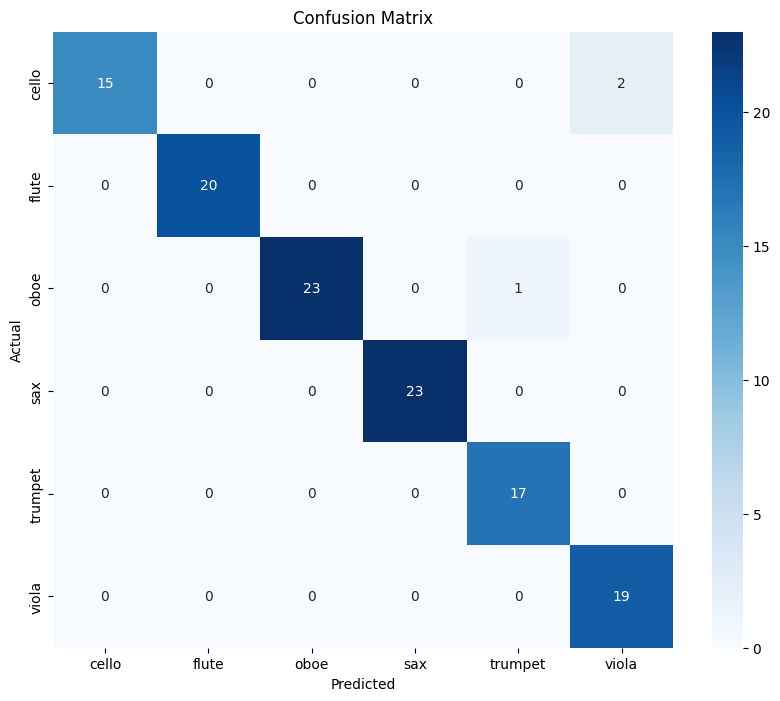

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

# Оцінка моделі на тестових даних
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

# Прогнозування міток для тестових даних
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Оцінка якості моделі
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=encoder.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

# Додатковий код для візуалізації матриці плутанини (за бажанням)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [32]:
import os
import librosa
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# === Завантаження моделі та scaler/encoder
model = load_model("ann_model.h5")
scaler = joblib.load("scaler.pkl")
encoder = joblib.load("labelencoder.pkl")

# === Шлях до папки з URMP
dataset_path = r"C:\Users\Вовчик\Downloads\URMP\Dataset"

# === Коди інструментів
instrument_codes = {
    "vn": "viola",     # ти навчив як "viola", тож тут правильно
    "va": "viola",
    "vc": "viola",
    "fl": "flute",
    "ob": "oboe",
    "tpt": "trumpet",
    "tba": "trumpet",
    "tbn": "trumpet",
    "sax": "saxophone",
    # якщо хочеш double bass як cello
}

# === Функція витягнення ознак з аудіо
def extract_features(file_path):
    y, sr = librosa.load(file_path, mono=True, duration=5)
    chroma_stft = np.mean(librosa.feature.chroma_stft(y=y, sr=sr))
    rmse = np.mean(librosa.feature.rms(y=y))
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spec_bw = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfccs = [np.mean(m) for m in mfcc]
    return np.array([chroma_stft, rmse, spec_cent, spec_bw, rolloff, zcr] + mfccs)

# === Основний цикл класифікації
results = []

for root, _, files in os.walk(dataset_path):
    for fname in files:
        if fname.lower().endswith(".wav") and not fname.startswith("._"):
            file_path = os.path.join(root, fname)
            fname_lower = fname.lower()
            try:
                # Визначення очікуваних інструментів (унікальні)
                expected = {
                    full for code, full in instrument_codes.items()
                    if code in fname_lower
                }

                # Витяг ознак
                features = extract_features(file_path).reshape(1, -1)
                features_scaled = scaler.transform(features)
                prediction = model.predict(features_scaled)
                pred_label = encoder.inverse_transform([np.argmax(prediction)])[0]

                # Порівняння з очікуванням
                correct = pred_label in expected if expected else None

                results.append({
                    "File": fname,
                    "Prediction": pred_label,
                    "Expected": ", ".join(expected) if expected else "—",
                    "Correct": correct
                })

                print(f"{fname} → {pred_label} {'✅' if correct else '❌' if expected else '(?)'}")

            except Exception as e:
                print(f"❌ Error processing {fname}: {e}")

# === Аналіз результатів
df = pd.DataFrame(results)

if not df.empty and "Correct" in df.columns:
    valid = df[df["Correct"].notna()]
    acc = round(valid["Correct"].mean() * 100, 1)
    print(f"\n🎯 Загальна точність: {acc}% ({len(valid)} з {len(df)} файлів)")
    print(valid.to_string(index=False))
else:
    print("⚠️ Не вдалося обробити жоден файл або не визначено очікувань.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
AuMix_01_Jupiter_vn_vc.wav → viola ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
AuSep_1_vn_01_Jupiter.wav → viola ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
AuSep_2_vc_01_Jupiter.wav → viola ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
AuMix_02_Sonata_vn_vn.wav → viola ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
AuSep_1_vn_02_Sonata.wav → viola ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
AuSep_2_vn_02_Sonata.wav → viola ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
AuMix_03_Dance_fl_cl.wav → viola ❌
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
AuSep_1_fl_03_Dance.wav → viola ❌
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
AuSep_2_cl_03_Dance.wav → viola (?)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
AuMix_04_Allegro_fl_fl.wav → viola ❌
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
AuSep_1_fl_04_Allegro.wav → viola ❌
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
AuSep_2_fl_04_Allegro.wav → viola ❌
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
AuMix_05_Entertainer_tpt_tpt.wav → trumpet ✅
1/1 ━━━━━━━━━━━━━━━